# Modelo de Genereacion Musical LoFi
### By: Juan José Goyeneche


### Instalar dependencias necesarias
- TensorFlow:biblioteca de código abierto para computación numérica y aprendizaje automático desarrollada por Google. Facilita la creación de modelos

- pretty-midi: Biblioteca de Python que proporciona herramientas para manipular y extraer información de archivos con formato MIDI, a difefrencia del otro proyecto que importamos un archivo wav, en este caso usaremos archivos midis como dataset para entrenar el modelo, y para generar el output.

- tqdm: biblioteca de Python que muestra una barra de progreso rápida y extensible para bucles e iterables

In [ ]:
!pip install -q tensorflow pretty-midi tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 42.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.2 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
import numpy as np
import pretty_midi
import os
import pickle
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import random

### Declarar Rutas
Declaramos las rutas que usaremos en nuestro proyecto para poder acceder a ellas de manera simpl, tambien nos conectamos a nuestro google drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

base = '/content/drive/MyDrive/Musiko/LoFiModel'
data = f'{base}/Data'

data_piano = f'{data}/piano'
data_lofi = f'{data}/lofi'
data_drums = f'{data}/drums'

models = f'{base}/models'
generated = f'{base}/generated'



Mounted at /content/drive


### Leer Midi
Se utiliza la libreria pretty midi para extraer información de cada midi, en esta funcion se saca la informacion en crudo, que nota se toca (Pitch), cuando se inicia a tocar (start), cuando se termina (end) y con que intensidad se toca la nota (velocity).

https://pypi.org/project/pretty-midi

Todo esto se almacenara en eventos = []

In [ ]:

def leer_midi(path):
    midi = pretty_midi.PrettyMIDI(str(path)) # le el archivo midi

    eventos = []

    for i in midi.instruments:#se recorre cada pista de instrumento del midi
        # Convertimos cada nota en dos eventos
        for nota in i.notes: # se recorre cada nota que toca el instrumento
            eventos.append({ # dos eventos cuando inicia la nota
                "tiempo": nota.start,
                "tipo": "on",
                "pitch": nota.pitch, # la nota
                "vel": nota.velocity # cuan fuerte se toca
            })
            eventos.append({
                "tiempo": nota.end, # cuando termina la nota
                "tipo": "off",
                "pitch": nota.pitch,
                "vel": nota.velocity
            })

    return eventos

    Procesa MIDIs de melodía y convierte a tokens
    
    Token map:
    - 0-127: NOTE_ON
    - 128-255: NOTE_OFF  
    - 256-355: TIME_SHIFT (0.01s cada uno)
    - 356-387: VELOCITY (bins de 4)


In [ ]:

def eventos_a_tokens(eventos):

    # Ordenamos por tiempo que suceden los eventos
    eventos = sorted(eventos, key=lambda e: e["tiempo"])

    tokens = []
    tiempo_actual = 0.0
    i = 0

    while i < len(eventos): #iteramos sobre los eventos

        ev = eventos[i] # evento actual
        delta = ev["tiempo"] - tiempo_actual # tiempo desde ultimo evento procesado

        # Cuantizamos el tiempo en pasos de 10 ms
        if delta > 0.01:
            pasos = int(delta / 0.01)

            while pasos > 0:
                step = min(99, pasos) #maximo de tiempo de token .99
                tokens.append(256 + step) # 256-355: TIME_SHIFT (0.01s cada uno)
                pasos -= step

            tiempo_actual = ev["tiempo"]

        # Agrupamos eventos muy cercanos (≈ simultáneos)
        t_obj = ev["tiempo"]
        grupo = []
        while i < len(eventos) and abs(eventos[i]["tiempo"] - t_obj) < 0.005:
            grupo.append(eventos[i])
            i += 1

        # Codificamos pitch + velocity
        for e in grupo:
            vel_idx = min(e["vel"] // 4, 31)
            tokens.append(356 + vel_idx)

            if e["tipo"] == "on":
                tokens.append(e["pitch"])
            else:
                tokens.append(e["pitch"] + 128)

        tiempo_actual = t_obj

    if len(tokens) > 100:
        return tokens
    return None

### Lee todos los midis
Lee todos los midis y usa las funciones anteriores para poder procesar las carpetas y convertir los midis a nuestros tokens

In [ ]:
def procesar_carpeta(carpeta):

    archivos = list(Path(carpeta).rglob("*.mid")) # busca todos los midis dentro de la carpeta
    secuencias = []

    print(f"Procesando {len(archivos)} ")

    for archivo in tqdm(archivos): # tqdm libreria barra de progreso
        eventos = leer_midi(archivo)  # extrae los eventos

        tokens = eventos_a_tokens(eventos) # convierte eventos a token
        if tokens:
            secuencias.append(tokens)

    return secuencias



In [ ]:
# Procesamos datasets
piano_seqs = procesar_carpeta(data_piano)
lofi_seqs = procesar_carpeta(data_lofi)

# Guardamos
f = open(f'{data}/piano01.pkl', 'wb')
pickle.dump(piano_seqs, f)
f.close()

f = open(f'{data}/lofi01.pkl', 'wb')
pickle.dump(lofi_seqs, f)
f.close()


print(f"Piano: {len(piano_seqs)},  Lo-fi: {len(lofi_seqs)}")

Procesando 292 


100%|██████████| 292/292 [03:54<00:00,  1.25it/s]


Procesando 93 


  9%|▊         | 8/93 [00:06<01:07,  1.25it/s]/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
100%|██████████| 93/93 [01:17<00:00,  1.21it/s]

Piano: 292,  Lo-fi: 82


In [ ]:
piano_seqs = f"{data}/piano.pkl"
lofi_seqs  = f"{data}/lofi.pkl"


### Aumentar Lofi
Estas siguientes funciones sirve basicamente para expandir el dataset, nuestra carpeta lo fi, tiene alrededor de 94 midis (no muchos), por lo que este truco nos ayudara para crear "copias", de con nuevos ejemplos.

 Se basa basicamente con crear_sequence(seq,salto),
 Ej: si nosotros tenemos esta seq = C4 E4 G4 F4, y metemos salto = 2, nos regresara D4 F#4 A4 B4. Aunque obviamente lo trabaja en nuestra tokenisation por ejemplo C4 = pitch 60 (0-127)(0-255)(velocity y time time shift quedan igual)

In [ ]:
def crear_sequence(seq, salto):
    secuencia = []
    for token in seq: # cada token de la secuencia
        if token >= 256:  # no es nota (volcity o time shift)
            secuencia.append(token)
        elif token < 128:
            secuencia.append(max(0, min(127, token + salto))) #nota actual +- salto de semitonos
        else:
            secuencia.append(max(128, min(255, token + salto))) #nota actual +- salto de semitonos
    return secuencia

def aumentar_datos(secuencias):
    aumentadas = list(secuencias)
    semitonos =  [-2, -1, 1, 2]
    for salto in semitonos: # genera 4 nuevas secuancias
        for i in secuencias:
            aumentadas.append(crear_sequence(i, salto))
    return aumentadas

f = open(f"{data}/lofi01.pkl", "rb")
lofi_seqs = pickle.load(f)
f.close()


lofi_aum = aumentar_datos(lofi_seqs)
print(f"Lo-fi aumentado: {len(lofi_seqs)} -> {len(lofi_aum)}")


Lo-fi aumentado: 82 -> 410


In [ ]:

def crear_ejemplos(secuencias, seq_len=512):

    inputs = [] # i
    targets = [] # i +1


    for seq in tqdm(secuencias):
        if len(seq) < seq_len + 1:


            repeticiones = (seq_len + 1) // len(seq) + 1
            extendida = (seq * repeticiones)[:seq_len + 1]
            if len(extendida) == seq_len + 1:
                inputs.append(extendida[:-1])
                targets.append(extendida[1:])
            continue

        for start in range(0, len(seq) - seq_len - 1, 128):
            chunk = seq[start:start + seq_len + 1]
            if len(chunk) == seq_len + 1:
                inputs.append(chunk[:-1])
                targets.append(chunk[1:])

    return inputs, targets


### Preparar DataSet
Agrupamos en chunks de 512, habran dos "slice" filas. X y Y/ input o target

X = [0 : size - 1]
Y = [0 + 1 : size]

Con la ayuda del método tf.data.Dataset.from_tensor_slices(), podemos obtener las porciones de una matriz en forma de objetos utilizando el método tf.data.Dataset.from_tensor_slices().
Syntax : tf.data.Dataset.from_tensor_slices(list)
Return : Return the objects of sliced elements.

Por ejemplo en nuestro caso seria la entrada de inputs y targets:

inputs = [
    [60, 356, 266, 62, ...512 tokens],
    [62, 356, 270, 64, ...512 tokens],
    [67, 360, 268, 71, ...512 tokens]
]

targets = [
    [356, 266, 62, ..., token512],
    [356, 270, 64, ..., token512],
    [360, 268, 71, ..., token512]
]
 donde obtendria primero
   input [0] = [60, 356, 266, 62, ...512 tokens]
  target [0] = [356, 266, 62, ..., token512]


https://www.tensorflow.org/api_docs/python/tf/data/Dataset
https://www.geeksforgeeks.org/python/tensorflow-tf-data-dataset-from_tensor_slices

tras esto se regresa con:

- shuffle(10000) → mezcla aleatoriamente los ejemplos

- batch(8) → mete 8 secuencias por batch

- prefetch() → hace carga asincrónica para velocidad máxima

In [ ]:
def crear_dataset(secuencias):
    inputs, targets = crear_ejemplos(secuencias) # generamos input y target

    if len(inputs) == 0:
        return None

    dataset = tf.data.Dataset.from_tensor_slices((
        tf.constant(inputs, dtype=tf.int32),
        tf.constant(targets, dtype=tf.int32)
    ))
    return dataset.shuffle(10000).batch(8).prefetch(tf.data.AUTOTUNE)

piano_dataset = crear_dataset(piano_seqs)
lofi_dataset = crear_dataset(lofi_aum)



100%|██████████| 410/410 [00:00<00:00, 67274.26it/s]


### Modelo
tf.keras.Sequential

#### Embedding
(388, 512, input_length=512),
- Vocabulario : Size de tokens = 388
- Dimension Embedding 512 o 724 porque no tenemos tantos datos y menos seria peor
- tamaño de batch : 512


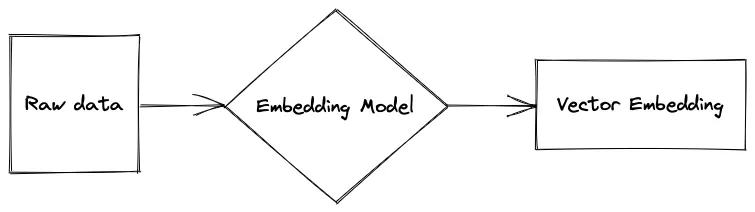

Nuestro embedding basicamente lo que logra es convertir nuestros tokens que ya de por si representan los eventos que representaban los midis, en vectores,Es como un **diccionario** que traduce palabras a coordenadas en un espacio multidimensional.

Por ejemplo:
En evento nosotros conociamos que teniamos cuando iniciaba y acababa una nota, la nota por la info del pitch y cuando acababa por el time, tambien la intensidad por el velocity.

Tras esto de estos dos eventos los convertimos en tokens para poder meterlo aca, conoceriamos la nota por el token 0 - 128 - 255, el time e intensidad por 0-387.

Ahora conoceremos esto por 512 numeros que serviran como coordenadas para formar un vector, eria algo como esto:

Evento.pitch = 60 -> Token 60 (C4) ->  [0.23, -0.45, 0.78, ..., 0.12]  (512 números)

Esto ayudara a que se encuentren relaciones matematicas mas facil encontrando que notas se relacionan entre si, con que frecuencia, e intencidad y cuando.

Entrada:  [batch=8, secuencia=512] -> números enteros
Salida:   [batch=8, secuencia=512, embedding=512] -> vectores

#### Primera LSTM
**LSTM** = Long Short-Term Memory
Las LSTM son redes neuronales recurrentes especiales. Pueden capturar dependencias a largo plazo en los datos. Su arquitectura única les permite recordar información relevante por mucho tiempo.

Estas redes son ideales para problemas complejos de aprendizaje automático.

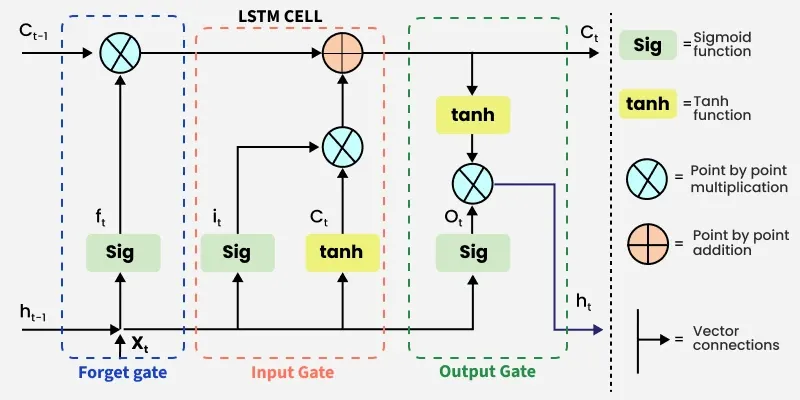

Le asignamos 1024 unidades para tener mas capacidad de aprendizaje, estas en si son neuronas

 tras esto establacer True inca que devuelve salida para cada uno de los 512 tokens

Un LSTM tiene
- input gate
- output gate
- Cell State
- Forget Gate

Basicamente en un ejemplo practico, se input el token de (Do) 60, lo recuerda tras esto el (Mi) y el (Sol), despues un toke de (time Shift),el modelo recordara que Do Mi Sol, pueden ir juntas y se ira repitiendo el acorda, de esta manera aprendera el acorde de Do y en base a lo que siga despues del time shift podra reconocer progresiones y escalas.

Entrada:  [batch=8, secuencia=512, embedding=512]
Salida:   [batch=8, secuencia=512, units=1024]

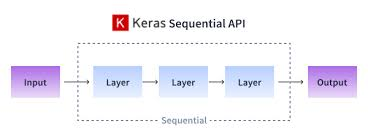

#### DropOut
tf.keras.layers.Dropout(0.2)

Apaga de manera aleatoria el 20% de las neuronas durante el entrenamiento.

Esto evita el overfitting y provoca que aprenda en vez de memorizar

#### Segunda LSTM
Esta aprendera basada en la primera salida


#### Salida
tf.keras.layers.Dense(388)
Capa conectada que predice las probabilidades para el siguiente token.

Entrada: Vector de 1024 números (salida de LSTM)
Multiplicación matricial -> Salida: Vector de 388 números (logits)-> 388 probabilidades (suman 1.0)

Ejemplo despues de Do las probabilidades seguramente sean:
- D = 10%
- E = 21%
- F# = 6%
- Time Shift = 15 %
- El resto hasta sumar 100


In [ ]:
def crear_modelo():
    model = tf.keras.Sequential([
        tf.keras.layers.Embedding(388, 512, input_length=512), #Embeding (512 o 728) de 388 tokens posibles
        tf.keras.layers.LSTM(1024, return_sequences=True),
        tf.keras.layers.Dropout(0.2), # pierde el 20 % de las neuronas (pa que no memorise)
        tf.keras.layers.LSTM(1024, return_sequences=True),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(388)
    ])
    return model

modelo = crear_modelo()
modelo.compile(
    optimizer=tf.keras.optimizers.Adam(0.001), # automatiza learning rate
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), # mide la no eficacia del modelo
    metrics=['accuracy'] # cuantas veces el predict salio correcro
)

modelo.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:


hist_piano = modelo.fit(
    piano_dataset,
    epochs=30
    )
modelo.save(f'{models}/model_piano01.keras')
print("Modelo guardado :)")

Epoch 1/30
3078/3078 ━━━━━━━━━━━━━━━━━━━━ 175s 54ms/step - accuracy: 0.2161 - loss: 3.0654
Epoch 2/30
3078/3078 ━━━━━━━━━━━━━━━━━━━━ 166s 54ms/step - accuracy: 0.5896 - loss: 1.4037
Epoch 3/30
3078/3078 ━━━━━━━━━━━━━━━━━━━━ 166s 54ms/step - accuracy: 0.6847 - loss: 1.0466
Epoch 4/30
3078/3078 ━━━━━━━━━━━━━━━━━━━━ 166s 54ms/step - accuracy: 0.7373 - loss: 0.8571
Epoch 5/30
3078/3078 ━━━━━━━━━━━━━━━━━━━━ 166s 54ms/step - accuracy: 0.7727 - loss: 0.7326
Epoch 6/30
3078/3078 ━━━━━━━━━━━━━━━━━━━━ 167s 54ms/step - accuracy: 0.7955 - loss: 0.6541
Epoch 7/30
3078/3078 ━━━━━━━━━━━━━━━━━━━━ 167s 54ms/step - accuracy: 0.8108 - loss: 0.6011
Epoch 8/30
3078/3078 ━━━━━━━━━━━━━━━━━━━━ 166s 54ms/step - accuracy: 0.8202 - loss: 0.5681
Epoch 9/30
3078/3078 ━━━━━━━━━━━━━━━━━━━━ 166s 54ms/step - accuracy: 0.8283 - loss: 0.5410
Epoch 10/30
3078/3078 ━━━━━━━━━━━━━━━━━━━━ 166s 54ms/step - accuracy: 0.8330 - loss: 0.5240
Epoch 11/30
3078/3078 ━━━━━━━━━━━━━━━━━━━━ 166s 54ms/step - accuracy: 0.8375 - loss: 0.50

In [ ]:

modelo.compile(
    optimizer=tf.keras.optimizers.Adam(0.0005), # con pasos mas cortos
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

hist_lofi = modelo.fit(lofi_dataset, epochs=35)
modelo.save(f'{models}/model_final01.keras')

f = open(f'{models}/history.pkl', 'wb')
pickle.dump(hist_lofi.history, f)
f.close()

print("modelo Guardado :)")

Epoch 1/35
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.3037 - loss: 3.9621
Epoch 2/35
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.3960 - loss: 2.6279
Epoch 3/35
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.4165 - loss: 2.4391
Epoch 4/35
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.4388 - loss: 2.2202
Epoch 5/35
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.4850 - loss: 2.0061
Epoch 6/35
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.5078 - loss: 1.8760
Epoch 7/35
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.5359 - loss: 1.7269
Epoch 8/35
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.5623 - loss: 1.5904
Epoch 9/35
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.5931 - loss: 1.4771
Epoch 10/35
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.6168 - loss: 1.3646
Epoch 11/35
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.6552 - loss: 1.2037
Epoch 12/35
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy:

In [ ]:
modelo = tf.keras.models.load_model(f'{models}/model_final01.keras')

def crear_seed():
    acordes = [
        [60, 64, 67],
        [57, 60, 64],
        [62, 65, 69],
        [65, 69, 72],
        [67, 71, 74],

        [60, 65, 67],  # Csus2
        [60, 62, 67],  # Csus4
        [57, 62, 64],  # Asus4

        [60, 64, 69],  # C add9 (sin la 7ma)
        [57, 60, 65],  # Am add9
        [62, 67, 69],  # Dm add9

        [60, 64, 70],  # C7 (Do - Mi - Sib)
        [57, 60, 67],  # Am7 (La - Do - Sol)
        [65, 69, 72],  # Fmaj7 (Fa - La - Do - Mi)
    ]
    # Selecciona acorde al azar
    acorde = random.choice(acordes)
    seed = []
    # token de time-shift inicial (356–375 )
    seed.append(356 + random.randint(12, 18))

    for i in acorde:
        seed.append(i) # adjunta las notas del acorde semilla

    # token de time-shift inicial
    seed.append(256 + random.randint(35, 55))

    for i in acorde:
        seed.append(i + 128) # adjunta las notas del acorde semilla en note off pa callarlas

    return seed


In [ ]:

def generar(length=3000, temp=1.0):
    generado = crear_seed()

    for _ in tqdm(range(length), desc=f"Generand: "):
        # Toma los últimos 512 tokens (o todos si hay menos)
        entrada = generado[-512:] if len(generado) >= 512 else generado
        # Rellena con ceros si la entrada es menor a 512
        entrada = entrada + [0] * (512 - len(entrada))
        # Convierte a tensor para pasarlo al modelo
        entrada = tf.constant([entrada])

        # Predicción del modelo para el siguiente token
        pred = modelo(entrada, training=False)

        #  la predicción del ultimo token de la secuencia y temperatura para ajustar distribucion
        pred = pred[0, -1, :] / temp
        pred = tf.nn.softmax(pred) # convierte a probabilidades = 1

        # indices ordenados de mayor a menor probabilidad
        sorted_idx = tf.argsort(pred, direction='DESCENDING')
        # ordena probabilidad
        sorted_probs = tf.gather(pred, sorted_idx)

        cumsum = tf.cumsum(sorted_probs) #  suma acumulada

        nucleus_size = tf.where(cumsum >= 0.9)[0] #donde la suma acumulada supere 90
        if len(nucleus_size) > 0: # si hay mas de uno con +.90
            nucleus_size = nucleus_size[0] + 1
            nucleus_idx = sorted_idx[:nucleus_size] # extraer esos nucleos
            nucleus_probs = sorted_probs[:nucleus_size]
            # normalizar para que vuelva a sumar 1 y no solo mas de .90
            nucleus_probs = nucleus_probs / tf.reduce_sum(nucleus_probs)
            # elige aleatoriamente de forma logaritmica
            token_idx = tf.random.categorical([tf.math.log(nucleus_probs + 1e-10)], 1)[0,0]
            # Reconvierte a token nota
            token = int(nucleus_idx[token_idx].numpy())
        else:
            # Reconvierte a token nota
            token = int(sorted_idx[0].numpy())
        # mete la nota a la cacnion
        generado.append(token)

    return generado

In [ ]:
def convertirAMidi(tokens):
    notas = []
    tiempo = 0.0
    vel = 64
    activas = {}

    for token in tokens:
        if 256 <= token < 356:
            tiempo += ((token - 256) * 0.01)
        elif 356 <= token < 388:
            vel = (token - 356) * 4
        elif token < 128:
            activas[token] = tiempo
        elif 128 <= token < 256:
            pitch = token - 128
            if pitch in activas:
                notas.append({
                    'pitch': pitch,
                    'start': activas[pitch],
                    'end': tiempo,
                    'vel': max(50, vel - 10)
                })
                del activas[pitch]

    return notas

In [ ]:
def agregar_vinilo(midi, duracion):
    vinilo = pretty_midi.Instrument(program=127)

    t = 0.0
    while t < duracion:
        pitch = random.randint(20, 35)
        dur = random.uniform(0.05, 0.2)
        v = random.randint(22, 35)

        vinilo.notes.append(pretty_midi.Note(
            velocity=v,
            pitch=pitch,
            start=t,
            end=t + dur
        ))
        t += random.uniform(0.1, 0.3)

    midi.instruments.append(vinilo)

In [ ]:
def guardar_midi(tokens, filename, bpm=78):
    midi = pretty_midi.PrettyMIDI(initial_tempo=bpm)

    notas = convertirAMidi(tokens)
    if len(notas) == 0:
        return

    piano_notas = []
    guitar_notas = []
    bass_notas = []

    for nota in notas:
        pitch = nota['pitch']
        if pitch < 48:
            bass_notas.append(nota)
        elif pitch < 72:
            if random.random() < 0.3:
                guitar_notas.append(nota)
            else:
                piano_notas.append(nota)
        else:
            piano_notas.append(nota)

    piano = pretty_midi.Instrument(program=4)
    guitar = pretty_midi.Instrument(program=27)
    bass = pretty_midi.Instrument(program=33)

    for i in piano_notas:
        piano.notes.append(pretty_midi.Note(
            velocity=i['vel'],
            pitch=i['pitch'],
            start=i['start'],
            end=i['end']
        ))

    for i in guitar_notas:
        guitar.notes.append(pretty_midi.Note(
            velocity=max(40, i['vel'] - 20),
            pitch=i['pitch'],
            start=i['start'],
            end=i['end']
        ))

    for i in bass_notas:
        bass.notes.append(pretty_midi.Note(
            velocity=i['vel'] + 10,
            pitch=i['pitch'],
            start=i['start'],
            end=i['end']
        ))

    if len(piano.notes) > 0:
        midi.instruments.append(piano)
    if len(guitar.notes) > 0:
        midi.instruments.append(guitar)
    if len(bass.notes) > 0:
        midi.instruments.append(bass)

    finales = (nota['end'] for nota in notas)
    duracion = max(finales)
    agregar_vinilo(midi, duracion)

    midi.write(filename)

In [ ]:
configs = [
    {'temp': 0.85, 'len': 2500, 'bpm': 76, 'name': 'chill01'},
    {'temp': 1.0,  'len': 3000, 'bpm': 78,  'name': 'basco101'},
    {'temp': 2.0, 'len': 3000, 'bpm': 82,  'name': 'experiment01'},
    {'temp': 1.1,  'len': 3500, 'bpm': 78,  'name': 'jazzy01'},
]

num = 1

for i in configs:
    music = generar(length=i['len'], temp=i['temp'])
    filename = f"{generated}/lofi_{num}_{i['name']}.mid"
    guardar_midi(music, filename, bpm=i['bpm'])
    num += 1

from google.colab import files
num = 1

for i in configs:
    archivo = Path(generated).glob(f"lofi_{num}_*.mid")
    archivos = list(archivo)

    if len(archivos) > 0:
        files.download(str(archivos[0]))

    num += 1


Generand: 100%|██████████| 3500/3500 [02:24<00:00, 24.26it/s]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>